In [ ]:
# pip install -U scikit-learn
# pip install matplotlib
# pip install Pillow
# pip install seaborn
# pip install opencv-python
# pip install mtcnn
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow import keras
from keras.models import load_model
from sklearn.model_selection import train_test_split
from keras.layers import  Dense, Flatten, Conv2D, Rescaling, BatchNormalization, MaxPooling2D, Dropout
import matplotlib.pyplot as plt
import os
import pickle
from glob import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import random
import cv2
from mtcnn.mtcnn import MTCNN
detector = MTCNN()

In [ ]:
FOLDER_IMAGES = './datasets/dmd/binary_labels'
FOLDER_IMAGES_AWAKE = './datasets/dmd/binary_labels/awake_lite'
FOLDER_IMAGES_DROWSY = './datasets/dmd/binary_labels/0_drowsy'
IMG_SIZE = (180, 180)
INPUT_SHAPE =  IMG_SIZE + (3,)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
MODEL_SAVE_FOLDER = './models/cnn/cnn_simple/'
EPOCHS = 30

Total images: 8
<class 'list'>
./datasets/dmd/binary_labels/awake_lite/0.jpg
./datasets/dmd/binary_labels/awake_lite/1.jpg
./datasets/dmd/binary_labels/awake_lite/2.jpg
./datasets/dmd/binary_labels/awake_lite/3.jpg
./datasets/dmd/binary_labels/awake_lite/4.jpg
./datasets/dmd/binary_labels/awake_lite/5.jpg
./datasets/dmd/binary_labels/awake_lite/6.jpg
./datasets/dmd/binary_labels/awake_lite/7.jpg
b'./datasets/dmd/binary_labels/awake_lite/0.jpg'


UnknownError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} SyntaxError: not a PNG file
Traceback (most recent call last):

  File "C:\Users\david\miniconda3\envs\keras\lib\site-packages\tensorflow\python\ops\script_ops.py", line 271, in __call__
    ret = func(*args)

  File "C:\Users\david\miniconda3\envs\keras\lib\site-packages\tensorflow\python\autograph\impl\api.py", line 642, in wrapper
    return func(*args, **kwargs)

  File "C:\Users\david\miniconda3\envs\keras\lib\site-packages\tensorflow\python\data\ops\dataset_ops.py", line 1035, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "C:\Users\david\AppData\Local\Temp\ipykernel_20500\4151510780.py", line 22, in image_generator
    image = preprocess_image(image_path)

  File "C:\Users\david\AppData\Local\Temp\ipykernel_20500\4151510780.py", line 12, in preprocess_image
    img = plt.imread(image_path)

  File "C:\Users\david

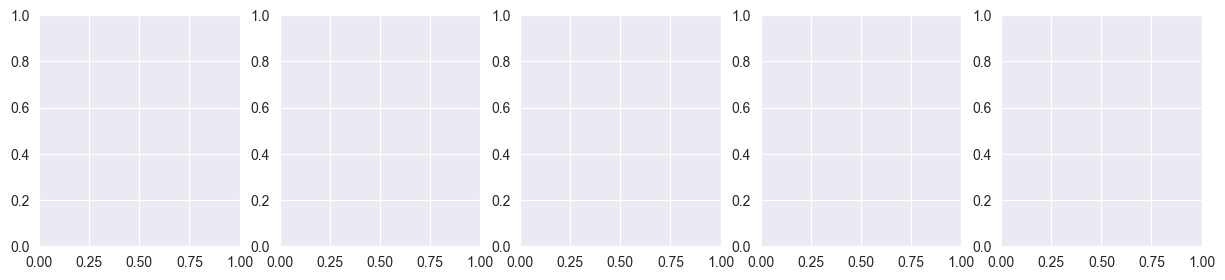

In [47]:
image_paths = [FOLDER_IMAGES_AWAKE+'/'+filename for filename in os.listdir(FOLDER_IMAGES_AWAKE)
               if os.path.isfile(os.path.join(FOLDER_IMAGES_AWAKE, filename))]

image_count = len(image_paths)
print('Total images: {}'.format(image_count))
print(type(image_paths))
for path in image_paths:
    print(path)

def crop_image(image, bounding_box):
    x1, y1, x2, y2 = bounding_box['box']
    cropped_image = image[y1:y2, x1:x2]
    return cropped_image

def preprocess_image(image_path):
    print(image_path)
    img = plt.imread(image_path)
    # faces = detector.detect_faces(img)
    # img = crop_image(img, faces[0])
    img = img.resize(IMG_SIZE)
    img_array = img_to_array(img)
    img_array = tf.image.resize(img_array, INPUT_SHAPE[:2])
    return img_array / 255.0

def image_generator(image_paths):
    for image_path in image_paths:
        image = preprocess_image(image_path)
        print(image.shape)
        yield image, 1  # Yield the image and label

dataset = tf.data.Dataset.from_generator(
    image_generator,
    output_signature=(
        tf.TensorSpec(shape=INPUT_SHAPE, dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    ),
    args=[image_paths]
)
# Split the dataset into train and validation sets
train_dataset = dataset.skip(int(image_count * 0.8)).batch(BATCH_SIZE)
validation_dataset = dataset.take(int(image_count * 0.2)).batch(BATCH_SIZE)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (image, label) in enumerate(train_dataset.take(5)):
    ax = axes[i]
#     ax.imshow(image.numpy().astype("uint8"))
    ax.axis("off")
plt.tight_layout()
plt.show()
